In [1]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import torch
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # For parallel execution



In [2]:
# File paths
old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5"

In [3]:
# with h5py.File(old_file_path, 'r') as old_data:
#     # Extract parameter values
#     P_old = old_data['P'][:]
#     J_e_primes = P_old[:, 0]
#     b_1_primes = P_old[:, 1]
#     b_2_primes = P_old[:, 2]
#     f_0_primes = P_old[:, 6]

#     # Find the shortest length
#     min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
#     # Function to randomly reduce the length of a list
#     def reduce_length(arr, target_length):
#         if len(arr) > target_length:
#             indices = np.random.choice(len(arr), target_length, replace=False)
#             return arr[indices]
#         return arr

#     # Reduce lengths to the shortest length
#     J_e_primes = reduce_length(J_e_primes, min_length)
#     b_1_primes = reduce_length(b_1_primes, min_length)
#     b_2_primes = reduce_length(b_2_primes, min_length)
#     f_0_primes = reduce_length(f_0_primes, min_length)
#     f_cr = 5.3e-3
#     f_0_values = f_0_primes/f_cr
#     # h_0_values = P_old[:, 4]

# time_grid = np.linspace(0, 1, 601)

In [4]:
# print(J_e_primes.min(), J_e_primes.max())
# print(b_1_primes.min(), b_1_primes.max())
# print(b_2_primes.min(), b_2_primes.max())
# print(f_0_values.min(), f_0_values.max())
# print(h_0_values.min(), h_0_values.max())

Constants

In [5]:
halton_sampler = Halton(d=7, scramble=True, seed=42)
halton_sequence = halton_sampler.random(n=300000).flatten()
halton_sequence = np.reshape(halton_sequence, (300000, 7))

In [6]:
ts_range = [10., 60.] # Characteristic time scale (s)
ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sequence[:,0]

h_range = [2e-6, 8e-6] # Characteristic height (m)
h_threshold = 0.5e-6
h_0_values = h_range[0] + (h_range[1] - h_range[0]) * halton_sequence[:,1]

J_e_range = [0., 40e-6] # Characteristic evaporation rate (m/minute)
J_e_primes = J_e_range[0] + (J_e_range[1] - J_e_range[0]) * halton_sequence[:,2]
J_e_primes = J_e_primes / 60. # Convert to m/s
J_e_values = J_e_primes * ts_halton / h_0_values

f_0_range = [0.0008, 0.002] # Characteristic fluorescence (%)
f_cr = 5.3e-3 # Critical fluorescence (%)
f_0_primes = f_0_range[0] + (f_0_range[1] - f_0_range[0]) * halton_sequence[:,3]
f_0_values = f_0_primes / f_cr

b_1_range = [-0.2, 2.] # (s^-1)
b_1_primes = b_1_range[0] + (b_1_range[1] - b_1_range[0]) * halton_sequence[:,4]
b_1_values = b_1_primes * ts_halton

b_2_range = [0., 2.] # (s^-1)
b_2_primes = b_2_range[0] + (b_2_range[1] - b_2_range[0]) * halton_sequence[:,5]
b_2_values = b_2_primes * ts_halton

# Rescale to be in the range 0.5 to 1.0
h_e_range = [0.5e-6, 1e-6] # Characteristic height (m)
h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence[:,6]
h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [7]:
rho = 1e0 # Water density (Kg/L)  [Why Kg/L and not g/L or Kg/m^3?]
P_c_hat = 12.1e-6 # (m/s)
Vw = 18e-6 # Molar volume of water (m^3/Mol)
c_0 = 300 # Serum Osmolarity (Mol/m^3)
sigma_0 = 0.045 # N/m
mu = 1.3e-3 # Pa.s
f_cr = 0.002 # Critical fluorescence (%)

# Solute parameters
Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

# Naperian extinction coefficient
eps_f = 1.75e7 # m^-1 M^-1
# transmittance parameter
fcr2 = rho * f_cr / Mw_FL


In [8]:
phi_values = eps_f*fcr2*h_0_values
Pc_values = P_c_hat*Vw*c_0/(h_0_values/ts_halton)

In [9]:
# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


In [10]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def generate_and_store_dataset():  
    valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index = [], [], [], [], [], []
    time_grid = np.linspace(0, 1, 601)  # Time grid for integration
    fixed_length = len(time_grid) 
    
    h_e = 0        # When we are assuming constant evaporation 
        
    def solve_single_instance(i):
        J_e, b_1, b_2, f_0, Pc, phi, h0, ts = (J_e_values[i], b_1_values[i], b_2_values[i],
                                            f_0_values[i], Pc_values[i], phi_values[i], h_0_values[i], ts_halton[i])
        y0 = [1.0, 1.0]
        sol = solve_ivp(
            differential_system,
            [0., 1.],
            y0,
            t_eval=time_grid,
            args=(J_e, b_1, b_2, h_e, Pc),
            method='LSODA',
        )
        
        if np.max(sol.y[0]) > 1.1 or np.min(sol.y[0]) < h_threshold / h0 or sol.y[0][-1] > 1.5 * np.min(sol.y[0]) or np.max(sol.y[1]) > 25:
            rejected_index.append(i)  # Store the index of rejected cases
            return None  # Skip rejected cases
        elif sol.y[0].shape[0] < fixed_length:
            rejected_index.append(i)  # Store the index of rejected cases
            return None
        else:
            h = sol.y[0]
            c = sol.y[1]
            f = f_0 * c
            I0 = 1 / calculate_I(h[0], f[0], phi, I_0=1.0)
            I = calculate_I(h, f, phi, I_0=I0)
            return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(300000))
    filtered_results = [res for res in results if res is not None]
    
    # Unpacking results into numpy arrays for efficient storage
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(new_file_path, "w") as hdf_file:
        hdf_file.create_dataset("h", data=valid_h)
        hdf_file.create_dataset("c", data=valid_c)
        hdf_file.create_dataset("f", data=valid_f)
        hdf_file.create_dataset("I", data=valid_I)
        hdf_file.create_dataset("p", data=valid_p)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index


In [11]:
start = time()
valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")

Total accepted parameter sets: 100795
Time taken: 88.60 seconds


In [12]:
datastore = h5py.File(new_file_path, 'r')
data_I = np.array(datastore["I"])
data_h = np.array(datastore["h"])
data_f = np.array(datastore["f"])

data_c = np.array(datastore["c"])
data_p = np.array(datastore["p"])

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


In [13]:
t = np.linspace(0,1,601)

Parameters for n=85206:
J_e: 5.7983082819496195e-06
b_1: 15.585361500077035
b_2: 12.279931219701702
h_e: 0.0
f_0: 0.3109638089167073
P_c: 0.10018046856273001
phi: 0.6587055673401017
ts_halton: 10.849633379360649
h_0: 7.076379809139378e-06
At t = 0, dh/dt: -5.592202332176192, dc/dt: 5.83720534084372


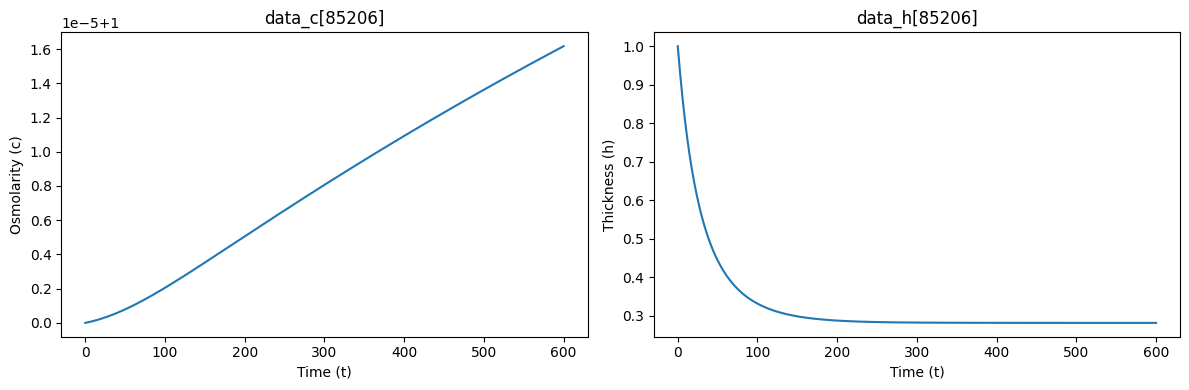

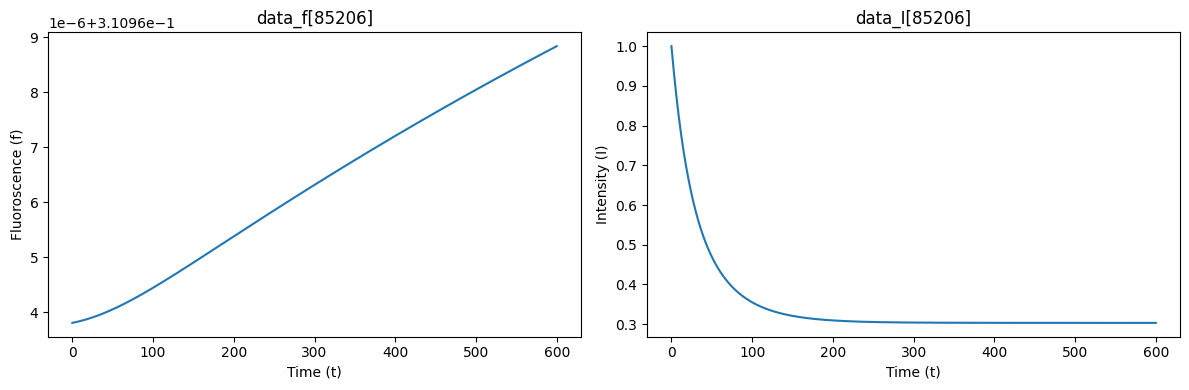

In [14]:
n = np.argmin(data_c[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=81497:
J_e: 0.5328037915671839
b_1: 39.07819407268677
b_2: 20.919503607759374
h_e: 0.0
f_0: 0.16657268193634017
P_c: 0.3631740702587232
phi: 0.7429517739705128
ts_halton: 44.3625117973294
h_0: 7.98142477179751e-06
At t = 0, dh/dt: -1.6398647814966112, dc/dt: 1.2561753501903388


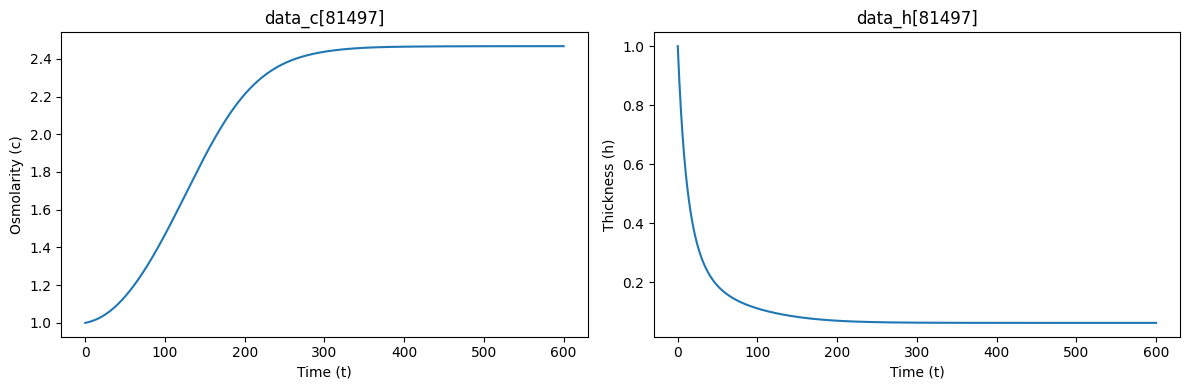

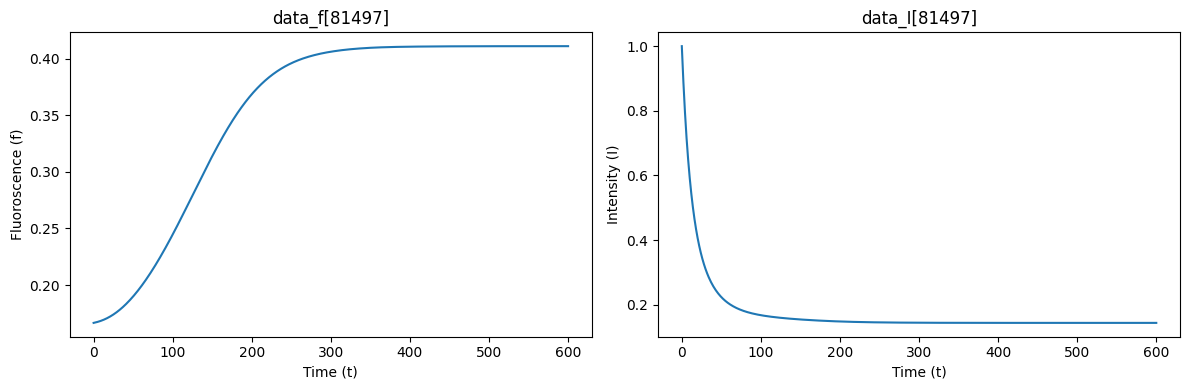

In [15]:
n = np.argmin(data_h[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=14304:
J_e: 3.400085308746209
b_1: -4.867310585620496
b_2: 61.53175627206328
h_e: 0.0
f_0: 0.15887991937905174
P_c: 0.33328569068814506
phi: 0.5862498150612815
ts_halton: 32.124772234341116
h_0: 6.297998013229768e-06
At t = 0, dh/dt: -80.41093210148921, dc/dt: 6.714192019153444


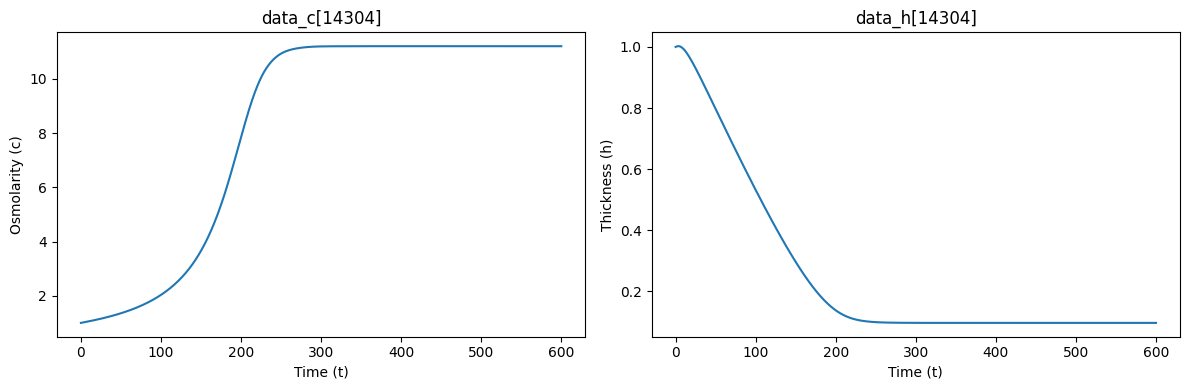

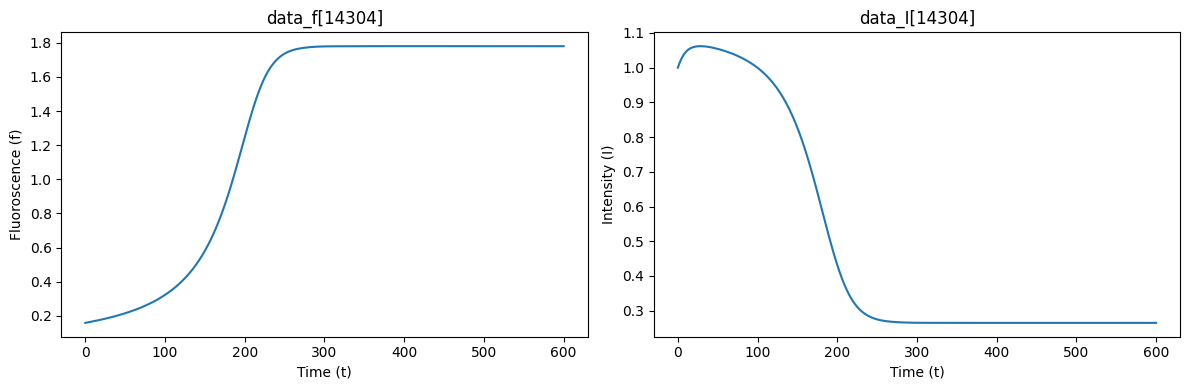

In [16]:
n = np.argmax(data_c[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=27666:
J_e: 0.002019843841259249
b_1: -5.5839079452316485
b_2: 59.958016590979206
h_e: 0.0
f_0: 0.2747153665847389
P_c: 0.5476015181500853
phi: 0.36407452465154955
ts_halton: 32.7789928153958
h_0: 3.9112006076852184e-06
At t = 0, dh/dt: -61.18757246635146, dc/dt: 5.458895087571911


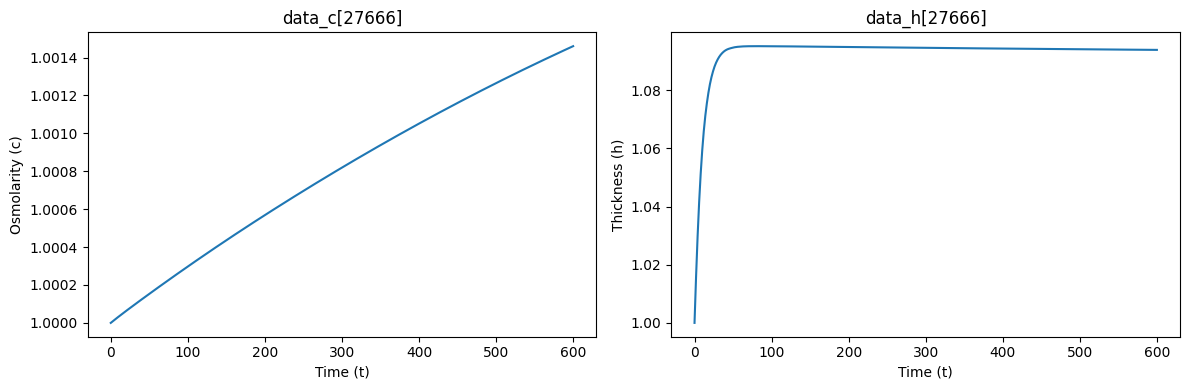

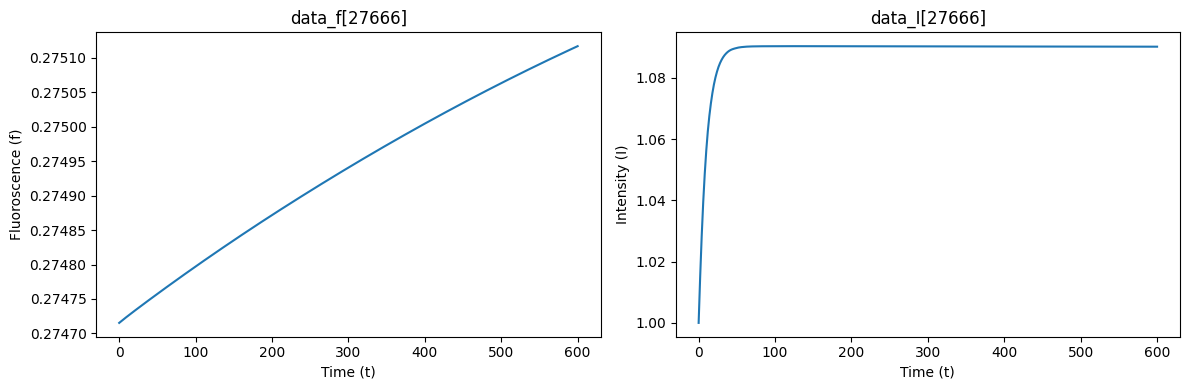

In [17]:
n = np.argmax(data_h[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=41498:
J_e: 1.0321030520883867
b_1: 7.0565935033665
b_2: 15.408222562082367
h_e: 0.0
f_0: 0.2934074516963318
P_c: 0.24246138435510894
phi: 0.7378463254242941
ts_halton: 29.413666887661428
h_0: 7.926577667415274e-06
At t = 0, dh/dt: -94.28392853423118, dc/dt: 2.2556083086067815


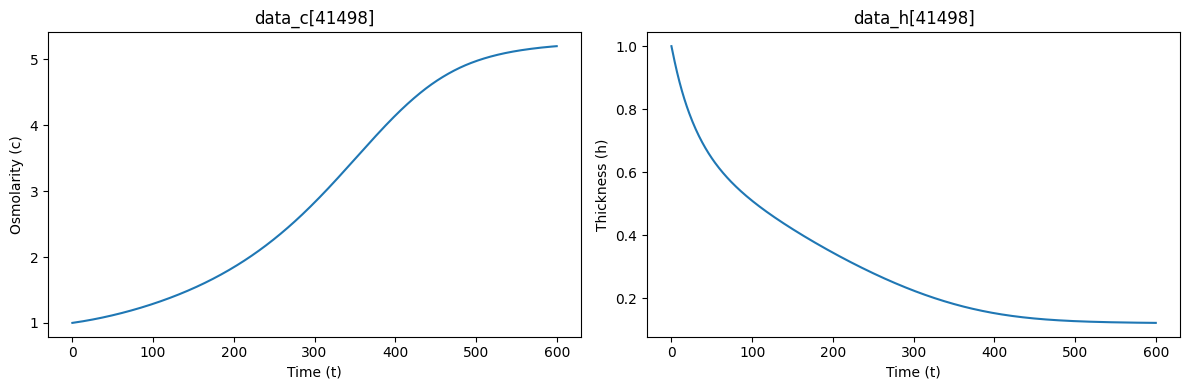

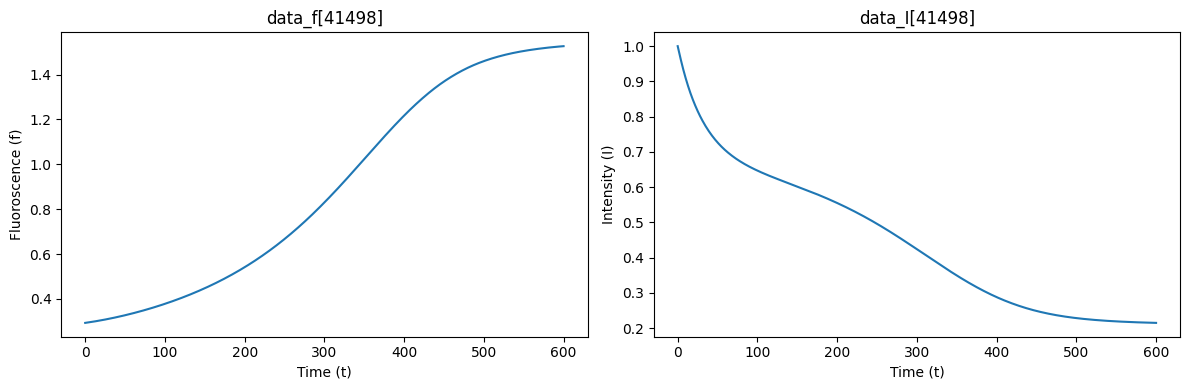

In [18]:
n = np.random.randint(88062)

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I[n])
axs[1].set_title('data_I[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Intensity (I)')

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

# Create a dictionary with the variables and their min/max values
data = {
    "Variable": ["h_0_values", "h_e_values", "J_e_values", "phi_values", "b_1_values", "b_2_values", "Pc_values"],
    "Min Value": [
        h_0_values.min(),
        h_e_values.min(),
        J_e_values.min(),
        phi_values.min(),
        b_1_values.min(),
        b_2_values.min(),
        Pc_values.min()
    ],
    "Max Value": [
        h_0_values.max(),
        h_e_values.max(),
        J_e_values.max(),
        phi_values.max(),
        b_1_values.max(),
        b_2_values.max(),
        Pc_values.max()
    ]
}

# Create a DataFrame for better visualization
table = pd.DataFrame(data)

# Display the table
print(table)

     Variable  Min Value   Max Value
0  h_0_values   0.000002    0.000008
1  h_e_values   0.062599    0.498555
2  J_e_values   0.000006   19.922588
3  phi_values   0.186171    0.744680
4  b_1_values -11.912739  119.907933
5  b_2_values   0.000018  119.654817
6   Pc_values   0.081917    1.956037


In [20]:
max_values_data_c = np.max(data_c, axis=1)
print(max_values_data_c.min(), max_values_data_c.max())

min_values_data_c = np.min(data_c, axis=1)
print(min_values_data_c.min(), min_values_data_c.max())

max_values_data_h = np.max(data_h, axis=1)
print(max_values_data_h.min(), max_values_data_h.max())

min_values_data_h = np.min(data_h, axis=1)
print(min_values_data_h.min(), min_values_data_h.max())

max_values_data_f = np.max(data_f, axis=1)
print(max_values_data_f.min(), max_values_data_f.max())

min_values_data_f = np.min(data_f, axis=1)
print(min_values_data_f.min(), min_values_data_f.max())

max_values_data_I = np.max(data_I, axis=1)
print(max_values_data_I.min(), max_values_data_I.max())

min_values_data_I = np.min(data_I, axis=1)
print(min_values_data_I.min(), min_values_data_I.max())

1.0000161677539765 11.206064238370066
0.9999999999999997 1.0000000000000002
0.9999999999999998 1.0999800801003612
0.06292712124098618 1.0000000000000002
0.15155746138029869 4.211124593103392
0.15094576996906686 0.3773583899559854
0.9999999999999998 2.529804812835297
0.04605785469101338 1.0000000000000002
